# Recipe 2 — Add a fund with no history

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/recipes/r2_asset_without_history.ipynb)

A private fund, a new product, a mandate that does not exist yet: you know what it earns, how much it moves and what drives it.

<a id="toc"></a>
## Contents

| | |
|---|---|
| **[1. The base](#s1)** | eight funds, six factors, nothing imposed |
| **[2. What you give](#s2)** | two sheets, four numbers |
| **[3. What the simulator does](#s3)** | the residual, and the shape it inherits |
| **[4. Check](#s4)** | the fund in the scenarios |
| **[5. What is refused](#s5)** | the two cells that cannot be empty |
| **[Where to look next](#next)** | the other recipes and the derivations |

---

<a id="s1"></a>
## 1. The base

<sub>[back to contents](#toc)</sub>

Eight funds, six factors, nothing imposed.

The base is `examples/inputs/recipe_base.xlsx`: eight funds, six factors, and
not one number imposed. Every mean, volatility, shape and beta below comes
from the monthly histories since June 2007.

`tags` says which factors each class may load on. `fit` means regressed, an
empty cell means a beta of zero, and the four other sheets are empty.

ETF returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/etf_cache_universe.csv: 232 months, 2007-06 to 2026-09
factor data read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/factors_cache.csv: 244 months, 2006-04 to 2026-07
FactorMarket(8 assets on 6 factors, generator='fleishman', 0 assets without history, 0 factors without history)


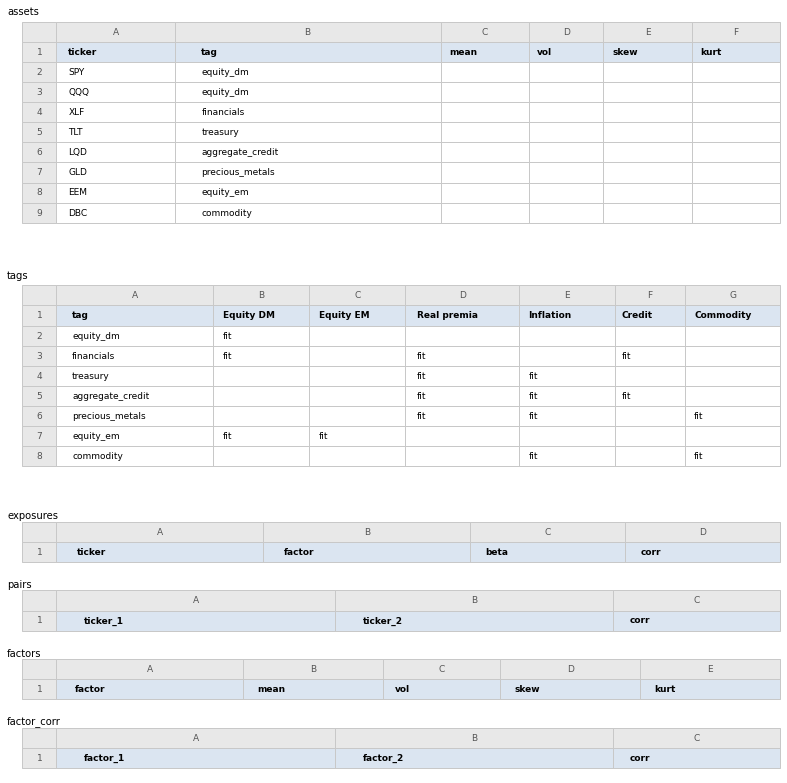

In [1]:
import os, sys, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30); pd.set_option("display.max_colwidth", 200)

ROOT = os.getcwd()                                   # the repo root, from wherever the notebook is opened
while not os.path.isdir(os.path.join(ROOT, "cvinemarketgen")) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)
try:
    import cvinemarketgen
except ImportError:                                  # Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/mamadouyamar/CVineMarketGen.git", "openpyxl"], check=True)
    import cvinemarketgen
from cvinemarketgen import load_etf_monthly, load_factor_data, MarketSpec, FactorMarket, show_workbook, show_change, show_sheet

FACTORS = ["Equity DM", "Equity EM", "Real premia", "Inflation", "Credit", "Commodity"]
A = lambda m: m * 1200                               # monthly mean -> percent a year
V = lambda v: v * np.sqrt(12) * 100                  # monthly vol  -> percent a year
spec = MarketSpec.read(os.path.join(ROOT, "examples", "inputs", "recipe_base.xlsx"))
tick = list(spec.assets["ticker"])
R = load_etf_monthly(tick, start="2007-04", cache=os.path.join(ROOT, "data", "etf_cache_universe.csv"))[tick]
F = load_factor_data(cache=os.path.join(ROOT, "data", "factors_cache.csv"))[FACTORS]
idx = R.index.intersection(F.index); R, F = R.loc[idx], F.loc[idx]
sim = FactorMarket(R, F, spec, generator="fleishman").fit()
print(sim)
show_workbook(spec, max_rows=8)

Eight assets on six factors, all from the histories. The generator is
Fleishman, which fits in a second; notebook 03 uses the C-vine, which takes
the tail dependence of the factors with it.

---

<a id="s2"></a>
## 2. What you give

<sub>[back to contents](#toc)</sub>

Two sheets, four numbers.

A row in `assets` with the ticker, a tag, a mean and a volatility, and a row in
`tags` giving that tag a beta on every factor it carries. Numbers, not `fit`:
there is no history to regress.

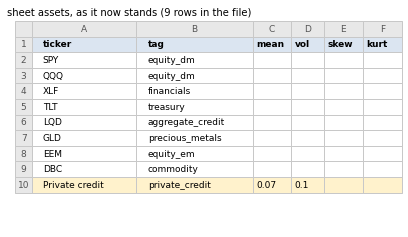

In [2]:
asset_row = {"ticker": "Private credit", "tag": "private_credit", "mean": 0.07, "vol": 0.10}
tag_row = {"tag": "private_credit", "Equity DM": 0.2, "Credit": 0.6}
spec_2 = spec.add("assets", asset_row).add("tags", tag_row)
show_change(spec_2, "assets", asset_row, max_rows=10)

And the tag row that gives it its betas.

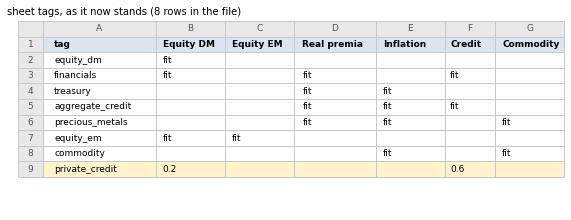

In [3]:
show_change(spec_2, "tags", tag_row, max_rows=10)

Nine rows in `assets` now, eight of them the listed funds. The `tags` sheet has
a row with two numbers and four empty cells, and an empty cell is a beta of zero.

---

<a id="s3"></a>
## 3. What the simulator does

<sub>[back to contents](#toc)</sub>

The residual, and the shape it inherits.

The factors carry $\boldsymbol\beta' \boldsymbol\Sigma_f \boldsymbol\beta$ of
the variance, and the residual takes the rest:

$$
\sigma_e^2 = v^2 - \boldsymbol\beta' \boldsymbol\Sigma_f \boldsymbol\beta ,
\qquad \alpha = m - \boldsymbol\beta' \boldsymbol\mu_f ,
$$

with $m$ and $v$ the mean and volatility you gave. With no history there is no
residual shape to estimate, so the residual is drawn close to normal, skewness
0 and kurtosis 3.1, the flattest a Johnson SU reaches.

The report says which rule fired.

In [4]:
sim_2 = sim.with_spec(spec_2)
sim_2.report.loc[["Private credit"], ["history", "value", "fit", "zero", "mean source", "vol source", "skew source", "resid vol"]]

,history,value,fit,zero,mean source,vol source,skew source,resid vol
Private credit,False,2,0,4,workbook,workbook,normal,0.019111


Two betas from the tag row, four factors at zero, mean and volatility from the
workbook, shape from the fallback.

---

<a id="s4"></a>
## 4. Check

<sub>[back to contents](#toc)</sub>

The fund in the scenarios.

Simulate, and read the fund's four moments against what was asked.

In [5]:
X2 = sim_2.simulate(20000, seed=4)
c = sim_2.check(X2)["assets"].loc[["Private credit"]].astype({"mean target": float, "vol target": float})
pd.DataFrame({"mean (%/yr)": [A(float(c["mean target"])), A(float(c["mean simulated"]))],
              "vol (%/yr)": [V(float(c["vol target"])), V(float(c["vol simulated"]))],
              "skewness": [np.nan, float(c["skew simulated"])], "kurtosis": [np.nan, float(c["kurt simulated"])]},
             index=["asked", "simulated"]).round(2)

,mean (%/yr),vol (%/yr),skewness,kurtosis
asked,7.00,10.00,NaN,NaN
simulated,6.84,9.98,-0.53,4.95


Both numbers come back: 6.84 against the 7.00 percent a year asked, 9.98
against 10.00. The shape was never given, and it is not normal either,
skewness -0.53 and kurtosis 4.95. It comes from Equity DM and Credit through
the two betas, so a fund with no history is not a Gaussian fund.

---

<a id="s5"></a>
## 5. What is refused

<sub>[back to contents](#toc)</sub>

The two cells that cannot be empty.

An asset with no history has nothing to estimate a scale from. The mean and
the volatility are required, and `fit` has no meaning.

In [6]:
for label, sp in [("no volatility", spec.add("assets", {"ticker": "Private credit", "tag": "private_credit", "mean": 0.07}).add("tags", tag_row)),
                  ("fit in the tag row", spec.add("assets", {"ticker": "New fund", "tag": "equity_dm", "mean": 0.07, "vol": 0.10}))]:
    try:
        sim.with_spec(sp); print(label, "-> accepted")
    except ValueError as err:
        print(label, "-> refused:", err)

no volatility -> refused: asset 'Private credit' has no history: give its mean and vol in the assets sheet
fit in the tag row -> refused: asset 'New fund' has no history: give values for ['Equity DM'] instead of fit


To tie the new fund to a listed one, a correlation between the two, see
[recipe 4](r4_pair_correlation.ipynb). To give it a shape of its own, see
[recipe 3](r3_asset_targets.ipynb).

---

<a id="next"></a>
## Where to look next

<sub>[back to contents](#toc)</sub>

The whole universe in one file, fitted, checked and written out:
[notebook 03](../03_many_assets_factors.ipynb). The derivations, the feasible
shapes and the bounds: the methods note, `docs/methods-note.pdf`.

The other levers:

- [what an asset loads on](r1_exposures.ipynb)
- [an asset's mean, volatility and shape](r3_asset_targets.ipynb)
- [a correlation between two assets](r4_pair_correlation.ipynb)
- [a view on a factor](r5_factor_views.ipynb)
- [a factor with no history](r6_factor_without_history.ipynb)